# راهنمای جامع کتابخانه Albumentations

## مقدمه

کتابخانه Albumentations یکی از سریع‌ترین و قدرتمندترین ابزارهای افزایش داده (Data Augmentation) برای تصاویر است که در پروژه‌های بینایی ماشین و یادگیری عمیق کاربرد فراوانی دارد. این کتابخانه با پشتیبانی از عملیات متنوع و ترکیب‌پذیر، به شما کمک می‌کند تا مدل‌های مقاوم‌تر و دقیق‌تری بسازید.

### ویژگی‌های کلیدی Albumentations:
- سرعت بسیار بالا و پیاده‌سازی بهینه
- پشتیبانی از طیف وسیعی از تبدیلات هندسی و رنگی
- قابلیت استفاده در پروژه‌های PyTorch و TensorFlow
- پشتیبانی از ماسک، bounding box و keypoints
- ترکیب ساده چندین تبدیل با هم

### کاربردهای عملی Albumentations:
- افزایش داده برای آموزش شبکه‌های عصبی
- مقاوم‌سازی مدل در برابر نویز و تغییرات محیطی
- شبیه‌سازی شرایط واقعی (چرخش، برش، نویز، تغییر نور و ...)
- آماده‌سازی داده برای تشخیص اشیاء، تقسیم‌بندی تصویر و طبقه‌بندی

---

## نصب Albumentations

### نصب با pip

برای نصب Albumentations کافی است دستور زیر را اجرا کنید:

In [ ]:
!pip install albumentations[imgaug] opencv-python

### مستندات و منابع رسمی
- [مستندات رسمی Albumentations](https://albumentations.ai/docs/)
- [صفحه GitHub](https://github.com/albumentations-team/albumentations)
- [لیست تبدیلات و توابع](https://albumentations.ai/docs/api_reference/augmentations/)

> **نکته:** همیشه از مستندات رسمی برای مشاهده آخرین تغییرات و امکانات استفاده کنید.

## وارد کردن کتابخانه‌های مورد نیاز

In [2]:
import albumentations as A
import cv2
import numpy as np
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

def fix_persian_text(text):
    try:
        reshaped_text = arabic_reshaper.reshape(text)
        return get_display(reshaped_text)
    except:
        return text

c:\Users\mmd\.conda\envs\tf\lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## مثال ساده: افزایش داده با Albumentations

در این مثال یک تصویر را بارگذاری و چند تبدیل پایه‌ای روی آن اعمال می‌کنیم.

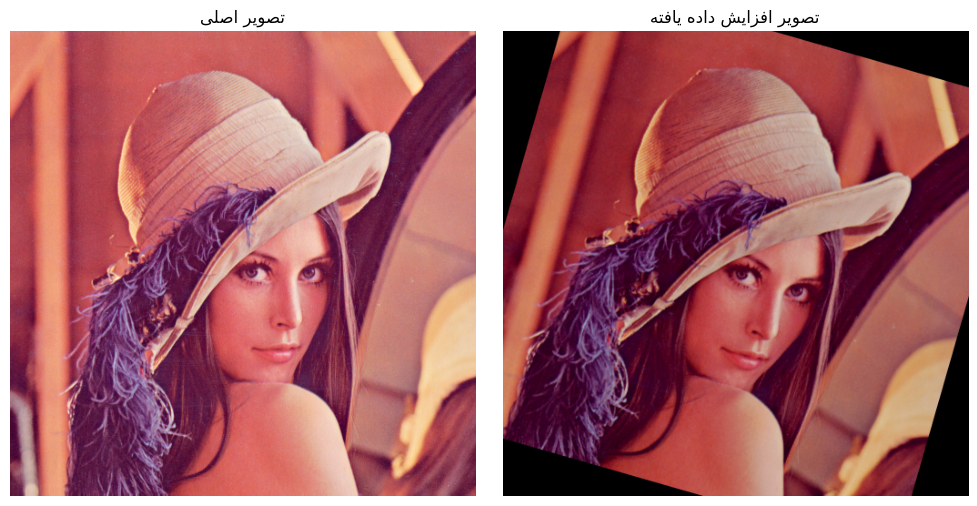

In [7]:
# بارگذاری تصویر نمونه
image = cv2.imread('./images/lenna.png')
if image is None:
    raise FileNotFoundError("تصویر './CA4/images/Lenna.png' پیدا نشد. مسیر را بررسی کنید.")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# تعریف یک pipeline ساده
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=30, p=0.5),
])

augmented = transform(image=image)
aug_img = augmented['image']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title(fix_persian_text('تصویر اصلی'))
axes[0].axis('off')
axes[1].imshow(aug_img)
axes[1].set_title(fix_persian_text('تصویر افزایش داده یافته'))
axes[1].axis('off')
plt.tight_layout()
plt.show()

## توضیح توابع و ورودی/خروجی‌ها

### A.Compose
- **کاربرد:** ترکیب چندین تبدیل به صورت پشت سر هم
- **ورودی:** لیستی از تبدیلات (Transforms)
- **خروجی:** یک شیء قابل فراخوانی که روی تصویر اعمال می‌شود

### A.HorizontalFlip
- **کاربرد:** قرینه‌سازی افقی تصویر
- **ورودی:** p (احتمال اعمال)
- **خروجی:** تصویر قرینه شده (در صورت رخ دادن)

### A.RandomBrightnessContrast
- **کاربرد:** تغییر تصادفی روشنایی و کنتراست
- **ورودی:** p (احتمال)، brightness_limit، contrast_limit
- **خروجی:** تصویر با روشنایی/کنتراست جدید

### A.Rotate
- **کاربرد:** چرخش تصادفی تصویر در بازه مشخص
- **ورودی:** limit (درجه چرخش)، p (احتمال)
- **خروجی:** تصویر چرخیده

---

## مثال‌های پیشرفته‌تر و کاربردی

### ۱. برش تصادفی و تغییر اندازه

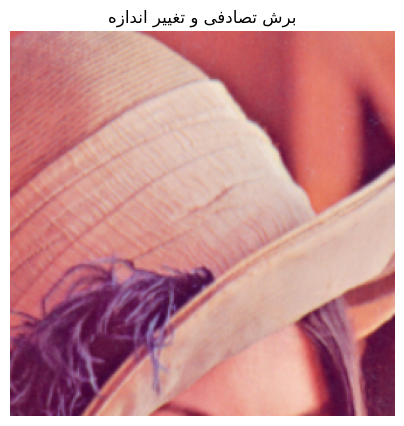

In [8]:
transform2 = A.Compose([
    A.RandomCrop(width=200, height=200),
    A.Resize(256, 256),
])
aug2 = transform2(image=image)['image']

plt.figure(figsize=(5,5))
plt.imshow(aug2)
plt.title(fix_persian_text('برش تصادفی و تغییر اندازه'))
plt.axis('off')
plt.show()

### ۲. افزودن نویز و تاری

C:\Users\mmd\AppData\Local\Temp\ipykernel_32548\2286851299.py:2: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.7),


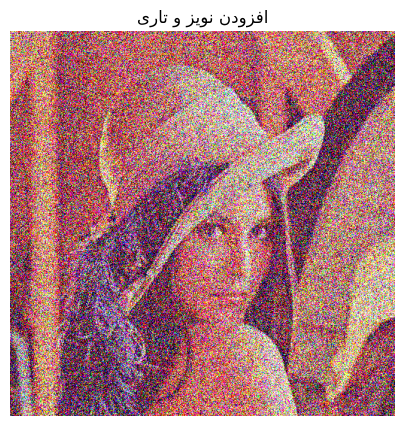

In [9]:
transform3 = A.Compose([
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.7),
    A.MotionBlur(blur_limit=7, p=0.5),
])
aug3 = transform3(image=image)['image']

plt.figure(figsize=(5,5))
plt.imshow(aug3)
plt.title(fix_persian_text('افزودن نویز و تاری'))
plt.axis('off')
plt.show()

### ۳. ترکیب چندین تبدیل پیچیده

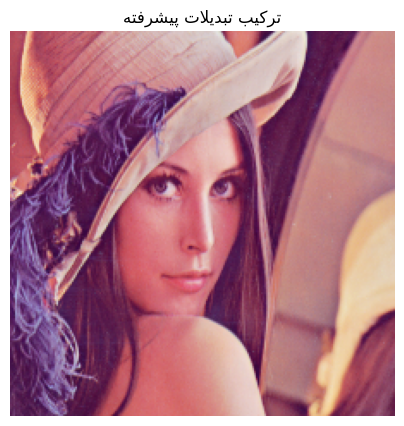

In [12]:
transform4 = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.5, 1.0)),
    A.OneOf([
        A.HueSaturationValue(p=0.5),
        A.RGBShift(p=0.5),
    ], p=1),
    A.CLAHE(p=0.3),
    A.ToGray(p=0.2),
])
aug4 = transform4(image=image)['image']

plt.figure(figsize=(5,5))
plt.imshow(aug4)
plt.title(fix_persian_text('ترکیب تبدیلات پیشرفته'))
plt.axis('off')
plt.show()

## نکات مهم و بهترین روش‌ها
- همیشه تصاویر را به صورت RGB بارگذاری کنید (OpenCV به صورت پیش‌فرض BGR است)
- مقدار p را برای کنترل احتمال اعمال هر تبدیل تنظیم کنید
- می‌توانید ماسک، bounding box و keypoints را نیز همراه تصویر وارد کنید
- برای پروژه‌های یادگیری عمیق، افزایش داده نقش کلیدی در بهبود عملکرد مدل دارد

---

## جمع‌بندی و منابع بیشتر

در این راهنما با Albumentations و کاربردهای آن آشنا شدید. برای یادگیری بیشتر به مستندات رسمی و مثال‌های پروژه‌های عملی مراجعه کنید.

- [مستندات Albumentations](https://albumentations.ai/docs/)
- [لیست تبدیلات](https://albumentations.ai/docs/api_reference/augmentations/)
- [GitHub Albumentations](https://github.com/albumentations-team/albumentations)